In [62]:
from os import chdir
from pathlib import Path

cwd = Path.cwd()
print(f"CWD: {cwd}")
if cwd.name == "code":
    chdir("..")
print(f"CWD: {Path.cwd()}")

CWD: /Users/haowen/Documents/Decentral RS/fed-learning-main
CWD: /Users/haowen/Documents/Decentral RS/fed-learning-main


In [64]:
import torch
import torch.nn as nn
import numpy as np
import networkx as nx
import random
from torch.utils.data import (DataLoader, Dataset, IterableDataset,
                              TensorDataset)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [66]:
from general.functions import LinearModel, generate_local_data, sample_neighbors, centralized_weighted_gradient_descent, decentralized_gradient_descent

In [68]:
from src.graphs import random_k_out_graph, create_graph, create_cycle_graph,create_scale_free_graph

In [70]:
from src.data_utils import create_batched_dataloaders, create_dataloader

In [72]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    # For CUDA
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # For deterministic behavior (slower)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(0)

In [74]:
def compute_theta_rmse(estimated_theta: torch.Tensor, true_theta: torch.Tensor, data_sizes) -> float:
    assert estimated_theta.shape == true_theta.shape, "Shape mismatch"
    d = true_theta.numel()
    total_n = sum(data_sizes)
    weighted_mse = 0.0
    
    for n_k in data_sizes:
        diff = estimated_theta - true_theta
        mse_k = torch.norm(diff).item() ** 2 / d
        weighted_mse += n_k * mse_k
        
    return (weighted_mse / total_n) ** 0.5

In [76]:
def compute_weighted_theta_rmse(estimated_thetas, true_theta, data_sizes):
    d = true_theta.numel()
    total_n = sum(data_sizes)
    weighted_mse = 0.0

    for theta_k, n_k in zip(estimated_thetas, data_sizes):
        diff = theta_k - true_theta
        mse_k = torch.norm(diff).item() ** 2 / d
        weighted_mse += n_k * mse_k

    return (weighted_mse / total_n) ** 0.5

In [78]:
def plot_rmse_vs_comm_cost(rmse_lists, comm_cost_lists, labels=None, title="RMSE vs Communication Cost", save_path=None):
    import matplotlib.pyplot as plt
    import numpy as np

    plt.figure(figsize=(8, 6))
    for i, (rmse_list, comm_list) in enumerate(zip(rmse_lists, comm_cost_lists)):
        cumulative_comm = np.cumsum(comm_list)
        label = labels[i] if labels else f"Method {i+1}"
        plt.plot(cumulative_comm, rmse_list, label=label)

    plt.xlabel("Cumulative Communication Cost (Bytes)")
    plt.ylabel("RMSE")
    plt.xlim(0, 20000) 
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"Plot saved to {save_path}")
    else:
        plt.show()

In [80]:
num_clients = 50
dim = 10
true_beta = torch.ones(dim, 1)
data_n = 200
graph_seed = 1
n_epoch = 100
sample_node = 10

In [82]:
data = [generate_local_data(data_n, true_beta, dim = dim) for _ in range(num_clients)]
loaders = [DataLoader(TensorDataset(X, y), batch_size=32, shuffle=True) for X, y in data]
data_sizes = [len(X) for X, _ in data]

In [84]:
k=0
X, y = data[k]
loader = DataLoader(TensorDataset(X, y), batch_size=300, shuffle=True)
for batch_x, batch_y in loader:
    print(batch_x.shape)
    

torch.Size([200, 10])


# Gradient Sharing

In [111]:
# Graph
#G = random_k_out_graph(n=num_clients, k=2, seed=graph_seed)
G = nx.complete_graph(num_clients)

In [113]:
para, rmse, comm ,beta_avg_list, beta_std_list= decentralized_gradient_descent(
    data_splits = data,               # list of (X, y) tuples for each node
    graph = G,                     # dict: node -> list of neighbors
    dim=dim,
    epochs=1000,
    lr=0.01,
    batch_size=32,
    device='cpu',
    true_beta= true_beta
)

In [90]:
beta_avg_array = np.stack(beta_avg_list, axis=0)

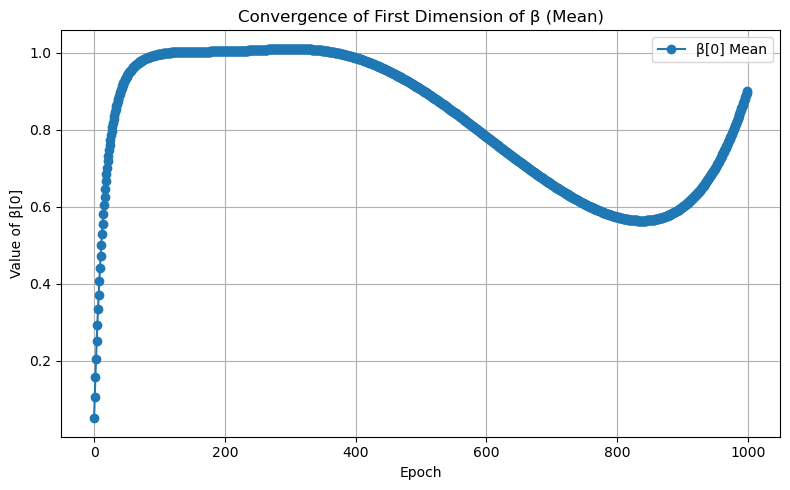

In [91]:
plt.figure(figsize=(8, 5))
plt.plot(beta_avg_array[:, 0], marker='o', label='β[0] Mean')
plt.xlabel('Epoch')
plt.ylabel('Value of β[0]')
plt.title('Convergence of First Dimension of β (Mean)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [92]:
beta_std_array = np.stack(beta_std_list, axis=0)

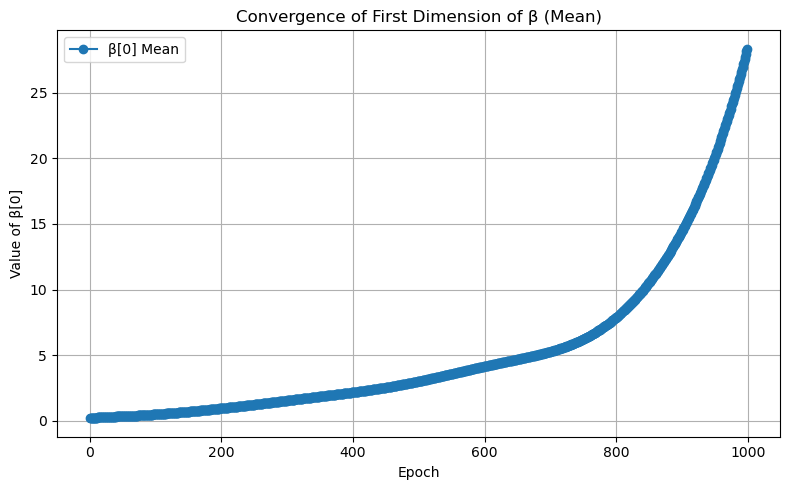

In [109]:
plt.figure(figsize=(8, 5))
plt.plot(beta_std_array[:, 9], marker='o', label='β[0] Mean')
plt.xlabel('Epoch')
plt.ylabel('Value of β[0]')
plt.title('Convergence of First Dimension of β (Mean)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Random-2-Out

In [14]:
decentral_theta_random2out, rmse_random2out, comm_random2out= decentralized_gd_with_sampling(
    data_loader = loaders, G = G, dim=dim, epochs=100, lr=0.1, sample_size=sample_node,
    true_beta=true_beta, data_sizes=data_sizes
)

In [15]:
global_rmse = compute_weighted_theta_rmse(decentral_theta_random2out, true_beta, data_sizes)

print(f"Decentralized Global RMSE (weighted): {global_rmse:.6f}")

Decentralized Global RMSE (weighted): 0.023445


# Random-5-out

In [282]:
# Graph
G = random_k_out_graph(n=num_clients, k=5, seed=graph_seed)

In [284]:
para, rmse, comm = decentralized_gradient_descent(
    data_splits = data,               # list of (X, y) tuples for each node
    graph = G,                     # dict: node -> list of neighbors
    dim=dim,
    epochs=100,
    lr=0.1,
    batch_size=32,
    device='cpu',
    true_beta= true_beta
)

In [273]:
para

{0: array([0.99346185, 0.9952774 , 0.9948643 , 0.9956467 , 0.9963222 ,
        0.9905115 , 0.9923171 , 0.9979051 , 1.0025463 , 0.99475914],
       dtype=float32),
 1: array([1.0030677, 1.0028088, 1.0008422, 1.0142778, 0.9998771, 1.007822 ,
        0.9929902, 0.9925225, 0.993801 , 0.9963985], dtype=float32),
 2: array([0.99916774, 1.0134364 , 1.0033396 , 0.9954124 , 0.9953384 ,
        1.0097798 , 0.9933604 , 0.9983733 , 1.0006797 , 1.0141481 ],
       dtype=float32),
 3: array([0.9920398 , 1.0039301 , 1.0007615 , 0.9964012 , 0.9982051 ,
        0.99217516, 1.0092351 , 1.0029722 , 0.9957368 , 0.9992012 ],
       dtype=float32),
 4: array([0.9970561 , 1.0009049 , 0.9861825 , 0.9974585 , 0.9911446 ,
        0.9979055 , 0.99692774, 0.99984825, 1.0152937 , 0.9874962 ],
       dtype=float32),
 5: array([0.9998547 , 0.99190974, 0.9882493 , 1.0063428 , 0.996549  ,
        0.99965984, 0.9955653 , 1.0073832 , 1.0037457 , 1.0074778 ],
       dtype=float32),
 6: array([1.0012511 , 1.0034002 , 1.00

In [256]:
decentral_theta_random5out,  rmse_random5out, comm_random5out = decentralized_gradient_descent(
    data_loader = loaders, G = G, dim=dim, epochs=100, lr=0.1, sample_size=sample_node,
    true_beta=true_beta, data_sizes=data_sizes
)

TypeError: decentralized_gradient_descent() got an unexpected keyword argument 'data_loader'

In [19]:
global_rmse = compute_weighted_theta_rmse(decentral_theta_random5out, true_beta, data_sizes)

print(f"Decentralized Global RMSE (weighted): {global_rmse:.6f}")

Decentralized Global RMSE (weighted): 0.022512


# Cycle

In [21]:
# Graph
G = create_cycle_graph(num_clients)

In [22]:
decentral_theta_cycle,  rmse_cycle, comm_cycle = decentralized_gd_with_sampling(
    data_loader = loaders, G = G, dim=dim, epochs=100, lr=0.1, sample_size=sample_node,
    true_beta=true_beta, data_sizes=data_sizes
)

In [23]:
global_rmse = compute_weighted_theta_rmse(decentral_theta_cycle, true_beta, data_sizes)

print(f"Decentralized Global RMSE (weighted): {global_rmse:.6f}")

Decentralized Global RMSE (weighted): 0.025954


# Scale-Free

In [25]:
# Graph
G = create_scale_free_graph(num_clients) 

In [26]:
decentral_theta_scalefree, rmse_scalefree, comm_scalefree =  decentralized_gd_with_sampling(
    data_loader = loaders, G = G, dim=dim, epochs=100, lr=0.1, sample_size=sample_node,
    true_beta=true_beta, data_sizes=data_sizes
)

In [27]:
global_rmse = compute_weighted_theta_rmse(decentral_theta_scalefree, true_beta, data_sizes)

print(f"Decentralized Global RMSE (weighted): {global_rmse:.6f}")

Decentralized Global RMSE (weighted): 0.027602


# Centralized

In [29]:
# Centralized training
theta_central, rmse_central, comm_central  = centralized_weighted_gradient_descent(
    data_splits = data, dim=dim, epochs=100, lr=0.1, true_beta=true_beta.T, data_sizes = data_sizes
)


In [30]:
rmse = compute_theta_rmse(theta_central, true_beta.T, data_sizes = data_sizes)
print(f"Centralized θ RMSE: {rmse:.6f}")

Centralized θ RMSE: 0.000911


In [131]:
torch.sqrt(torch.sum((theta_central - true_beta.T)**2)/(10 *num_clients ))

tensor(0.0001)

In [125]:
torch.sum((decentral_theta_random5out[1] - true_beta.T)**2)/10

tensor(3.1277e-05)

# Plot

Plot saved to rmse_vs_comm_cost.png


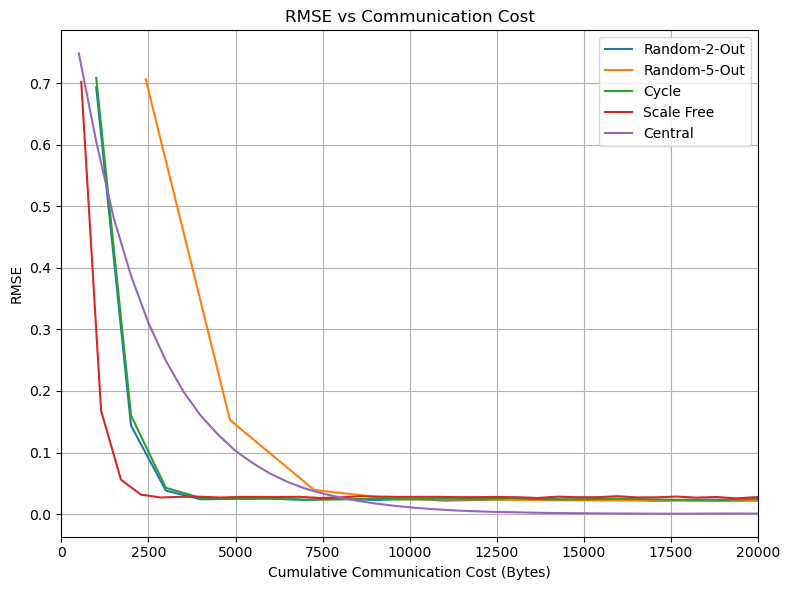

In [32]:
plot_rmse_vs_comm_cost(
    rmse_lists=[ rmse_random2out, rmse_random5out, rmse_cycle, rmse_scalefree, rmse_central],
    comm_cost_lists=[comm_random2out, comm_random5out, comm_cycle, comm_scalefree, comm_central],
    labels=["Random-2-Out", "Random-5-Out", "Cycle", "Scale Free", "Central"],
    save_path="rmse_vs_comm_cost.png"
)

In [33]:
# Graph
G = create_scale_free_graph(num_clients) 

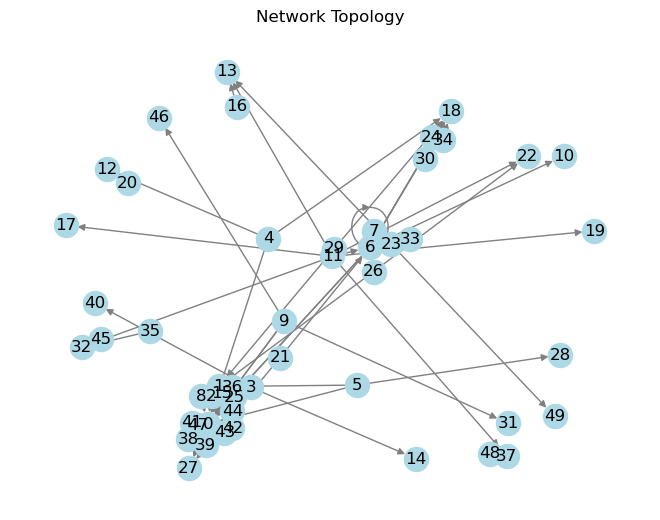

In [34]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(G)  # or nx.circular_layout(G), nx.kamada_kawai_layout(G), etc.
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray')
plt.title("Network Topology")
plt.show()

In [35]:
for node in G.nodes():
    neighbors = list(G.neighbors(node))
    print(f"Node {node}: neighbors -> {neighbors}")

Node 0: neighbors -> [1, 27]
Node 1: neighbors -> [2, 0]
Node 2: neighbors -> [0]
Node 3: neighbors -> [0, 14, 40]
Node 4: neighbors -> [0, 12, 18]
Node 5: neighbors -> [1, 0, 28]
Node 6: neighbors -> [6, 10, 0, 18]
Node 7: neighbors -> [6]
Node 8: neighbors -> [0]
Node 9: neighbors -> [0, 31, 46]
Node 10: neighbors -> []
Node 11: neighbors -> [6, 13, 17, 19, 22, 32, 37]
Node 12: neighbors -> []
Node 13: neighbors -> []
Node 14: neighbors -> []
Node 15: neighbors -> [0]
Node 16: neighbors -> [13]
Node 17: neighbors -> []
Node 18: neighbors -> []
Node 19: neighbors -> []
Node 20: neighbors -> [12]
Node 21: neighbors -> [6, 27]
Node 22: neighbors -> []
Node 23: neighbors -> [13, 49]
Node 24: neighbors -> [18]
Node 25: neighbors -> [0]
Node 26: neighbors -> [22, 1]
Node 27: neighbors -> []
Node 28: neighbors -> []
Node 29: neighbors -> [18, 1]
Node 30: neighbors -> [18]
Node 31: neighbors -> []
Node 32: neighbors -> []
Node 33: neighbors -> [23]
Node 34: neighbors -> [18]
Node 35: neighbo